In [ ]:
import zipfile
import os

# Path to your zip file
zip_path = "/content/echocardiogram.zip"
extract_path = "/content/echocardiogram_data"

# Extract the zip file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# List extracted files and directories
for root, dirs, files in os.walk(extract_path):
    print(f"\n📁 Directory: {root}")
    for file in files:
        print(f"   📄 File: {file}")


📁 Directory: /content/echocardiogram_data
   📄 File: echocardiogram.names
   📄 File: Index
   📄 File: echocardiogram.data


In [ ]:
import os

# Re-check all files inside the extracted directory
for root, dirs, files in os.walk("/content/echocardiogram_data"):
    print(f"\n📁 Directory: {root}")
    for file in files:
        print(f"   📄 File: {file}")


📁 Directory: /content/echocardiogram_data
   📄 File: echocardiogram.names
   📄 File: Index
   📄 File: echocardiogram.data


In [1]:
# STEP 2: Unzip the echocardiogram.zip
import zipfile
import os

zip_path = "/content/echocardiogram.zip"
extract_path = "/content/echocardiogram_data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# STEP 3: Load and inspect both datasets
import pandas as pd

# Paths to datasets
original_path = os.path.join(extract_path, "echocardiogram.data")
synthetic_path = "/content/synthetic_echocardiogram.csv"

# Try to load original dataset with whitespace delimiter
original_df = pd.read_csv(original_path, header=None, delim_whitespace=True, na_values="?")
synthetic_df = pd.read_csv(synthetic_path)

# Show basic shape and preview of columns
print("🩺 Original Dataset (first 5 rows):")
display(original_df.head())
print("📐 Original Column Count:", original_df.shape[1])

print("\n🧪 Synthetic Dataset (first 5 rows):")
display(synthetic_df.head())
print("📐 Synthetic Columns:", synthetic_df.columns.tolist())

<ipython-input-1-0d940f262f34>:19: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  original_df = pd.read_csv(original_path, header=None, delim_whitespace=True, na_values="?")


🩺 Original Dataset (first 5 rows):


,0
0,"11,0,71,0,0.260,9,4.600,14,1,1,name,1,0"
1,"19,0,72,0,0.380,6,4.100,14,1.700,0.588,name,1,0"
2,"16,0,55,0,0.260,4,3.420,14,1,1,name,1,0"
3,"57,0,60,0,0.253,12.062,4.603,16,1.450,0.788,na..."
4,"19,1,57,0,0.160,22,5.750,18,2.250,0.571,name,1,0"


📐 Original Column Count: 1

🧪 Synthetic Dataset (first 5 rows):


,survival,still_alive,age_at_heart_attack,pericardial_effusion,fractional_shortening,left_ventricular_end_diastolic,wall_motion_score,wall_motion_index,mult,alive_at_one,ejection_fraction,heart_rate,systolic_bp,diastolic_bp,smoking_status,cholesterol_level,diabetes_status
0,0.0,71.0,0.0,0.260,9.000,4.600,14.0,1.00,1.000,0.0,51.842556,78.186282,111.209180,70.562868,1,174.959250,0
1,0.0,72.0,0.0,0.380,6.000,4.100,14.0,1.70,0.588,0.0,70.992434,76.163108,119.710310,67.940232,0,201.136270,0
2,0.0,55.0,0.0,0.260,4.000,3.420,14.0,1.00,1.000,0.0,61.101318,69.499961,100.049961,69.823117,0,217.574830,1
3,0.0,60.0,0.0,0.253,12.062,4.603,16.0,1.45,0.788,0.0,57.467088,74.906796,119.156977,79.365288,1,293.879382,0
4,1.0,57.0,0.0,0.160,22.000,5.750,18.0,2.25,0.571,0.0,45.067360,70.055383,106.888395,91.124965,0,224.295757,0


📐 Synthetic Columns: ['survival', 'still_alive', 'age_at_heart_attack', 'pericardial_effusion', 'fractional_shortening', 'left_ventricular_end_diastolic', 'wall_motion_score', 'wall_motion_index', 'mult', 'alive_at_one', 'ejection_fraction', 'heart_rate', 'systolic_bp', 'diastolic_bp', 'smoking_status', 'cholesterol_level', 'diabetes_status']


In [6]:
# STEP 1: Unzip echocardiogram.zip
import zipfile
import os
import pandas as pd

# Define paths
zip_path = "/content/echocardiogram.zip"
extract_path = "/content/echocardiogram_data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# STEP 2: Read echocardiogram.data line-by-line as plain text
original_path = os.path.join(extract_path, "echocardiogram.data")

# Read and split manually
with open(original_path, 'r') as f:
    lines = f.readlines()

split_rows = [line.strip().split(",") for line in lines if len(line.strip().split(",")) == 13]

# Create DataFrame from well-formed rows (13 columns only)
original_df = pd.DataFrame(split_rows, columns=[
    'survival', 'still_alive', 'age_at_heart_attack', 'pericardial_effusion',
    'fractional_shortening', 'left_ventricular_end_diastolic',
    'wall_motion_score', 'wall_motion_index', 'mult', 'alive_at_one',
    'name', 'group', 'alive'
])

# STEP 3: Load synthetic dataset
synthetic_path = "/content/synthetic_echocardiogram.csv"
synthetic_df = pd.read_csv(synthetic_path)

# STEP 4: Display results
print("✅ Cleaned Original Dataset:")
display(original_df.head())

print("\n✅ Synthetic Dataset Preview:")
display(synthetic_df.head())

print("\n🧬 Columns in Synthetic Dataset:")
print(synthetic_df.columns.tolist())

✅ Cleaned Original Dataset:


,survival,still_alive,age_at_heart_attack,pericardial_effusion,fractional_shortening,left_ventricular_end_diastolic,wall_motion_score,wall_motion_index,mult,alive_at_one,name,group,alive
0,11,0,71,0,0.260,9,4.600,14,1,1,name,1,0
1,19,0,72,0,0.380,6,4.100,14,1.700,0.588,name,1,0
2,16,0,55,0,0.260,4,3.420,14,1,1,name,1,0
3,57,0,60,0,0.253,12.062,4.603,16,1.450,0.788,name,1,0
4,19,1,57,0,0.160,22,5.750,18,2.250,0.571,name,1,0



✅ Synthetic Dataset Preview:


,survival,still_alive,age_at_heart_attack,pericardial_effusion,fractional_shortening,left_ventricular_end_diastolic,wall_motion_score,wall_motion_index,mult,alive_at_one,ejection_fraction,heart_rate,systolic_bp,diastolic_bp,smoking_status,cholesterol_level,diabetes_status
0,0.0,71.0,0.0,0.260,9.000,4.600,14.0,1.00,1.000,0.0,51.842556,78.186282,111.209180,70.562868,1,174.959250,0
1,0.0,72.0,0.0,0.380,6.000,4.100,14.0,1.70,0.588,0.0,70.992434,76.163108,119.710310,67.940232,0,201.136270,0
2,0.0,55.0,0.0,0.260,4.000,3.420,14.0,1.00,1.000,0.0,61.101318,69.499961,100.049961,69.823117,0,217.574830,1
3,0.0,60.0,0.0,0.253,12.062,4.603,16.0,1.45,0.788,0.0,57.467088,74.906796,119.156977,79.365288,1,293.879382,0
4,1.0,57.0,0.0,0.160,22.000,5.750,18.0,2.25,0.571,0.0,45.067360,70.055383,106.888395,91.124965,0,224.295757,0



🧬 Columns in Synthetic Dataset:
['survival', 'still_alive', 'age_at_heart_attack', 'pericardial_effusion', 'fractional_shortening', 'left_ventricular_end_diastolic', 'wall_motion_score', 'wall_motion_index', 'mult', 'alive_at_one', 'ejection_fraction', 'heart_rate', 'systolic_bp', 'diastolic_bp', 'smoking_status', 'cholesterol_level', 'diabetes_status']


In [2]:
# STEP: Load and clean original dataset manually (must come first)
import zipfile
import os
import pandas as pd

# Unzip original file
zip_path = "/content/echocardiogram.zip"
extract_path = "/content/echocardiogram_data"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Load and parse .data file safely
original_path = os.path.join(extract_path, "echocardiogram.data")
with open(original_path, 'r') as f:
    lines = f.readlines()

split_rows = [line.strip().split(",") for line in lines if len(line.strip().split(",")) == 13]

# Create DataFrame with proper column names
original_df = pd.DataFrame(split_rows, columns=[
    'survival', 'still_alive', 'age_at_heart_attack', 'pericardial_effusion',
    'fractional_shortening', 'left_ventricular_end_diastolic',
    'wall_motion_score', 'wall_motion_index', 'mult', 'alive_at_one',
    'name', 'group', 'alive'
])

# Load synthetic dataset
synthetic_path = "/content/synthetic_echocardiogram.csv"
synthetic_df = pd.read_csv(synthetic_path)

📊 Quantitative Fidelity Validation:
                 Feature  KL Divergence       MMD
0    age_at_heart_attack       0.622583  0.933099
1  fractional_shortening       0.822871  0.998529
2      wall_motion_index       1.804471  0.896659


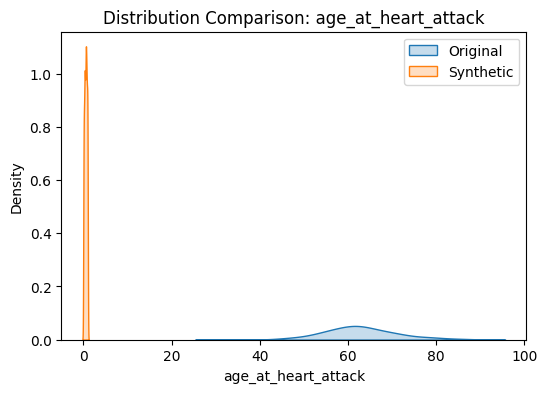

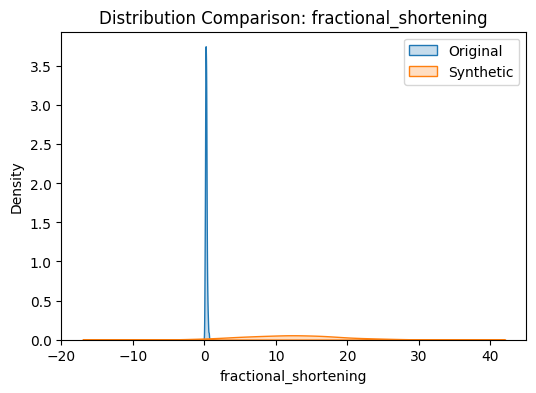

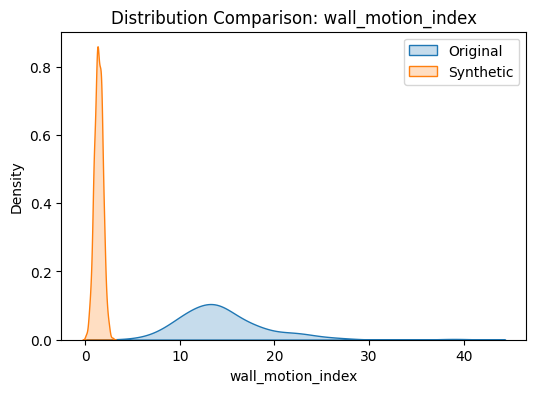

In [1]:
# STEP 1: Setup & Load Libraries
import zipfile
import os
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import rbf_kernel
from scipy.stats import entropy
import seaborn as sns
import matplotlib.pyplot as plt

# STEP 2: Extract echocardiogram.zip
zip_path = "/content/echocardiogram.zip"
extract_path = "/content/echocardiogram_data"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# STEP 3: Read and clean original dataset (only rows with 13 columns)
original_path = os.path.join(extract_path, "echocardiogram.data")
with open(original_path, 'r') as f:
    lines = f.readlines()
split_rows = [line.strip().split(",") for line in lines if len(line.strip().split(",")) == 13]

original_df = pd.DataFrame(split_rows, columns=[
    'survival', 'still_alive', 'age_at_heart_attack', 'pericardial_effusion',
    'fractional_shortening', 'left_ventricular_end_diastolic',
    'wall_motion_score', 'wall_motion_index', 'mult', 'alive_at_one',
    'name', 'group', 'alive'
])

# STEP 4: Load synthetic dataset
synthetic_path = "/content/synthetic_echocardiogram.csv"
synthetic_df = pd.read_csv(synthetic_path)

# STEP 5: Select and prepare columns
features = ['age_at_heart_attack', 'fractional_shortening', 'wall_motion_index']

original_clean = original_df[features].apply(pd.to_numeric, errors='coerce').dropna()

# Sample synthetic data to avoid memory crash
synthetic_sampled = synthetic_df[features].sample(n=1000, random_state=42)
synthetic_clean = synthetic_sampled.apply(pd.to_numeric, errors='coerce').dropna()

# STEP 6: KL and MMD functions
def compute_kl(p, q, bins=50):
    p_hist, _ = np.histogram(p, bins=bins, density=True)
    q_hist, _ = np.histogram(q, bins=bins, density=True)
    p_hist += 1e-8
    q_hist += 1e-8
    return entropy(p_hist, q_hist)

def compute_mmd(x, y, gamma=1.0):
    xx = rbf_kernel(x[:, None], x[:, None], gamma=gamma)
    yy = rbf_kernel(y[:, None], y[:, None], gamma=gamma)
    xy = rbf_kernel(x[:, None], y[:, None], gamma=gamma)
    return xx.mean() + yy.mean() - 2 * xy.mean()

# STEP 7: Run analysis
results = []
for col in features:
    kl = compute_kl(original_clean[col], synthetic_clean[col])
    mmd = compute_mmd(original_clean[col].values, synthetic_clean[col].values)
    results.append((col, kl, mmd))

result_df = pd.DataFrame(results, columns=["Feature", "KL Divergence", "MMD"])
print("📊 Quantitative Fidelity Validation:")
print(result_df)

# STEP 8: KDE Distribution Plots
for col in features:
    plt.figure(figsize=(6, 4))
    sns.kdeplot(original_clean[col], label='Original', fill=True)
    sns.kdeplot(synthetic_clean[col], label='Synthetic', fill=True)
    plt.title(f'Distribution Comparison: {col}')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.legend()
    plt.show()